In [29]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from unike.module.model import RotatE
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import gaussian_kde
import seaborn as sns

In [30]:
rotate_model = RotatE(
    ent_tol=151321,
    rel_tol=31,
    dim=1024,
    margin=6.0,
    epsilon=2.0,
)
rotate_model.load_checkpoint('checkpoints/rotate/all/multi/rotate-500.pth')
rotate_model.ent_embeddings

Embedding(151321, 2048)

In [31]:
nodes = pd.read_csv('../../../kg/kg_origin/nodes.csv').get(['node_index', 'node_type'])
id2type = {row['node_index']: row['node_type'] for _, row in nodes.iterrows()}

In [32]:
embeddings = rotate_model.ent_embeddings.weight.data.cpu().numpy()
embeddings.shape

(151321, 2048)

In [33]:
embeddings_pca = PCA(n_components=50).fit_transform(embeddings)
embeddings_2d = TSNE(n_components=2).fit_transform(embeddings_pca).T
embeddings_2d.shape

(2, 151321)

In [34]:
embeddings_2d

array([[-62.179718, -76.73257 , -93.45418 , ...,  48.23869 ,  62.021645,
         40.575535],
       [  2.729804,  40.206654,  52.000835, ...,  39.593674, -66.891136,
         27.61441 ]], dtype=float32)

In [35]:
types = list(id2type.values())

In [36]:

color_map = {
    'gene/protein': 'blue',
    'anatomy': 'cyan',
    'biological_process': 'magenta',
    'cellular_component': 'yellow',
    'disease': 'red',
    'drug': 'purple',
    'effect/phenotype': 'plum',
    'exposure': 'orange',
    'molecular_function': 'lightgreen',
    'pathway': 'sienna',
}
colors = [ color_map[t] for t in types]

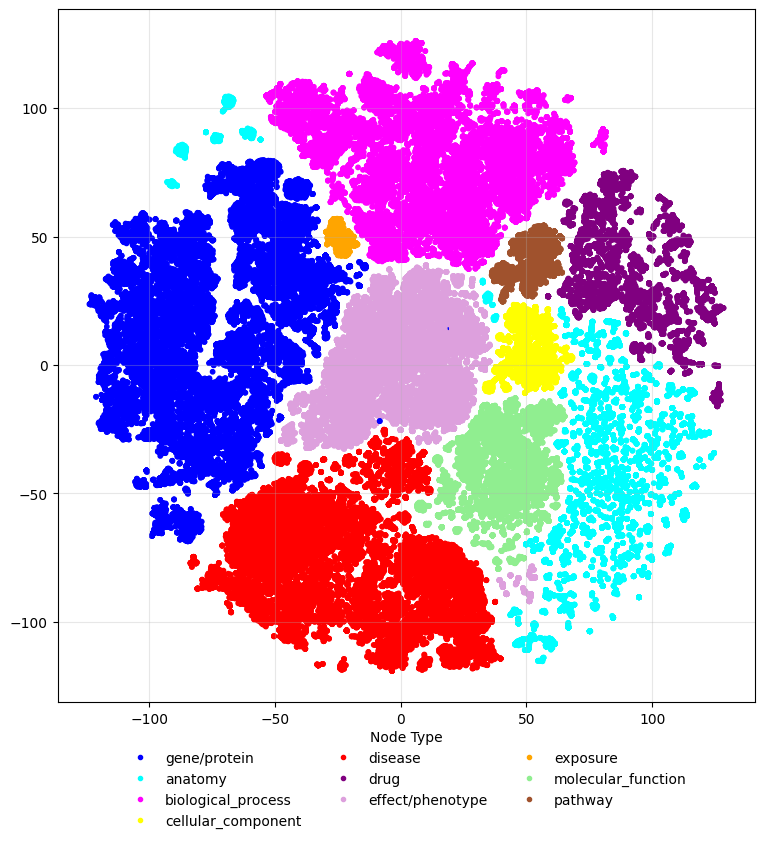

In [37]:
plt.figure(figsize=(9, 9))
scatter = plt.scatter(embeddings_2d[0, :], embeddings_2d[1, :], label=types, color=colors, s=10)
plt.grid(True, alpha=0.3)

legend_handles = [mlines.Line2D([], [], color=color_map[t], marker='o', linestyle='None', markersize=3, label=t) for t in color_map]
plt.legend(handles=legend_handles, title='Node Type', loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False)

plt.show()